# Neighbourhood Characteristics and House Prices Analysis

This analysis explores which neighbourhood characteristic — crime, deprivation or public transport accessibility — is most strongly associated with house prices across London LSOAs.

The analysis uses the cleaned dataset created in `data_preparation.ipynb`. Median house price in 2022 is used as the outcome variable. Crime is measured using the total number of recorded offences in 2022. Deprivation is measured using the **Index of Multiple Deprivation (IMD) 2019**, where higher scores indicate greater deprivation. Public transport accessibility is measured using **Average PTAI 2015**, where higher values indicate better access to public transport; the related PTAL categories are also used later to compare house prices across different accessibility levels.

The analysis begins with exploratory analysis of the main variables, followed by an examination of their individual relationships with house prices and, finally, a multiple regression analysis to assess their adjusted associations when considered together.

### 1. Load and Inspect the Prepared Dataset

The prepared dataset is loaded and briefly checked to confirm its dimensions, data types, missing values and duplicate LSOA records before beginning the analysis.

In [22]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, kruskal
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from statsmodels.stats.diagnostic import het_breuschpagan


DATA_PATH = Path("data/final_df.csv")
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("Duplicate LSOAs:", df["LSOA11CD"].duplicated().sum())
print("Missing values:", df.isna().sum().sum())
print(df.dtypes)
df.head()

Shape: (4746, 27)
Duplicate LSOAs: 0
Missing values: 0
Local Authority Code                        str
Local Authority Name                        str
LSOA11CD                                    str
LSOA Name                                   str
Median House Price 2022                   int64
Arson and Criminal Damage               float64
Burglary                                float64
Drug Offences                           float64
Miscellaneous Crimes Against Society    float64
Possession of Weapons                   float64
Public Order Offences                   float64
Robbery                                 float64
Theft                                   float64
Vehicle Offences                        float64
Violence Against the Person             float64
Total Crime 2022                        float64
IMD Score                               float64
Income Deprivation Score                float64
Employment Deprivation Score            float64
Education Deprivation Score      

,Local Authority Code,Local Authority Name,LSOA11CD,LSOA Name,Median House Price 2022,Arson and Criminal Damage,Burglary,Drug Offences,Miscellaneous Crimes Against Society,Possession of Weapons,...,Income Deprivation Score,Employment Deprivation Score,Education Deprivation Score,Health Deprivation Score,Crime Deprivation Score,Housing Deprivation Score,Living Environment Deprivation Score,Total Population 2015,Average PTAI 2015,PTAL
0,E09000002,Barking and Dagenham,E01000006,Barking and Dagenham 016A,205000,6.0,3.0,17.0,5.0,2.0,...,0.117,0.059,14.798,-0.359,-0.147,45.171,26.888,2040,22.45580,5
1,E09000002,Barking and Dagenham,E01000007,Barking and Dagenham 015A,350000,23.0,9.0,72.0,5.0,9.0,...,0.207,0.107,11.385,-0.027,0.846,50.420,25.995,2101,33.30230,6a
2,E09000002,Barking and Dagenham,E01000008,Barking and Dagenham 015B,190000,14.0,14.0,27.0,3.0,5.0,...,0.265,0.151,25.506,0.250,0.353,45.413,30.233,1566,7.39059,2
3,E09000002,Barking and Dagenham,E01000009,Barking and Dagenham 016B,360000,22.0,5.0,58.0,2.0,2.0,...,0.187,0.109,15.713,0.454,0.895,48.119,28.601,1775,38.36410,6a
4,E09000002,Barking and Dagenham,E01000010,Barking and Dagenham 015C,194000,71.0,48.0,162.0,11.0,10.0,...,0.169,0.073,11.762,-0.002,1.214,50.580,47.932,3195,32.28600,6a


### 2. Exploratory Data Analysis

Before examining individual relationships, the distributions of the main variables are explored to understand their central tendency, variability, skewness and potential outliers.

The initial EDA focuses on median house price, total crime, overall deprivation (IMD) and public transport accessibility (PTAI).

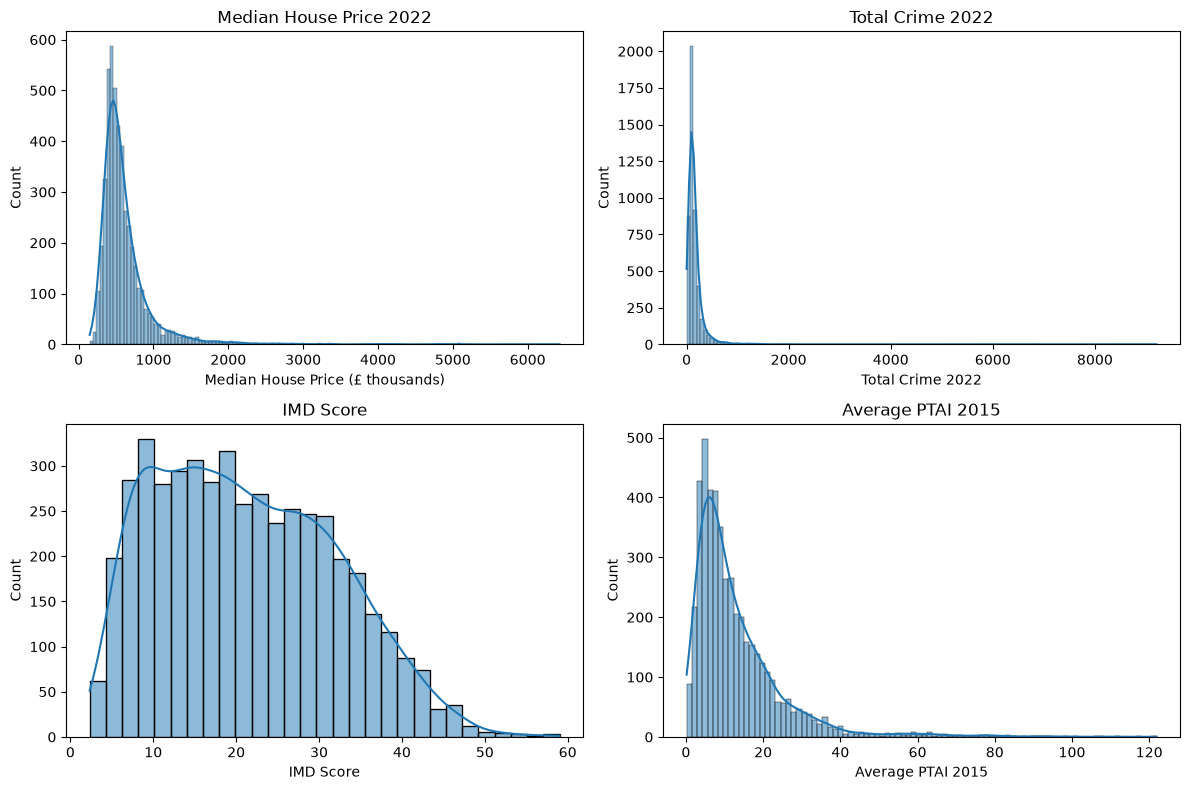

,count,mean,median,std,min,max,skewness
Median House Price 2022,4746.0,617638.82,520000.00,396233.02,147500.00,6425000.00,5.24
Total Crime 2022,4746.0,167.82,115.00,301.25,2.00,9206.00,17.51
IMD Score,4746.0,21.20,20.09,10.68,2.33,59.01,0.38
Average PTAI 2015,4746.0,13.23,9.47,12.32,0.19,121.89,2.92


In [23]:
main_cols = [
    "Median House Price 2022",
    "Total Crime 2022",
    "IMD Score",
    "Average PTAI 2015"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flatten(), main_cols):
    if col == "Median House Price 2022":
        sns.histplot(df[col] / 1000, kde=True, ax=ax)
        ax.set_xlabel("Median House Price (£ thousands)")
    else:
        sns.histplot(df[col], kde=True, ax=ax)
        ax.set_xlabel(col)
    ax.set_title(col)

plt.tight_layout()
plt.show()

summary = df[main_cols].describe().T
summary["median"] = df[main_cols].median()
summary["skewness"] = df[main_cols].skew()
summary = summary[["count", "mean", "median", "std", "min", "max", "skewness"]]
summary.round(2)

The distributions show clear differences between the four main variables. Median house prices are strongly right-skewed (skewness = 5.24), reflecting a relatively small number of extremely expensive neighbourhoods. Total crime is even more strongly right-skewed (17.51), with a small number of LSOAs recording exceptionally high crime counts.

Public transport accessibility is also positively skewed (2.92), while the IMD score is much more evenly distributed (skewness = 0.38).

The extreme observations are not automatically removed, as they may represent genuine characteristics of particular London neighbourhoods. Their influence will be examined further during the relationship and regression analyses.

### 3. Relationships with House Prices

This section examines how crime, deprivation and public transport accessibility are individually associated with median house prices across London LSOAs. The analysis begins by comparing the overall relationships using correlations and scatterplots. The results are then explored in more detail where additional patterns or unusual observations are identified.

**3.1 Overall Relationships**

A correlation matrix provides an initial overview of the relationships between house prices and the three neighbourhood characteristics, as well as the relationships between the characteristics themselves.

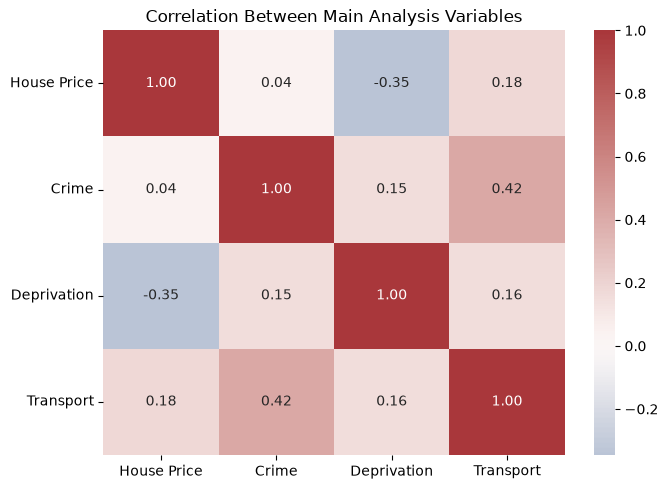

In [24]:
corr = df[main_cols].corr()

corr_cols = {
    "Median House Price 2022": "House Price",
    "Total Crime 2022": "Crime",
    "IMD Score": "Deprivation",
    "Average PTAI 2015": "Transport"
}

corr = corr.rename(index=corr_cols, columns=corr_cols)

plt.figure(figsize=(7, 5))

sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)

plt.title("Correlation Between Main Analysis Variables")
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

The correlation matrix suggests that deprivation has the clearest negative linear relationship with house prices (`r = -0.35`), while public transport accessibility shows a weaker positive relationship (`r = 0.18`) and total crime shows almost no linear relationship with house prices (`r = 0.04`).

Crime, deprivation and public transport accessibility are also related to one another, which will be important when they are considered together later in the multiple regression analysis.

To examine these relationships in more detail, house prices are plotted against each characteristic. Because house prices, total crime and public transport accessibility are highly right-skewed and contain several extreme values, both Pearson and Spearman correlations are calculated. Pearson measures the strength of a linear relationship and is more sensitive to extreme observations, while Spearman is based on ranks and is less affected by them.

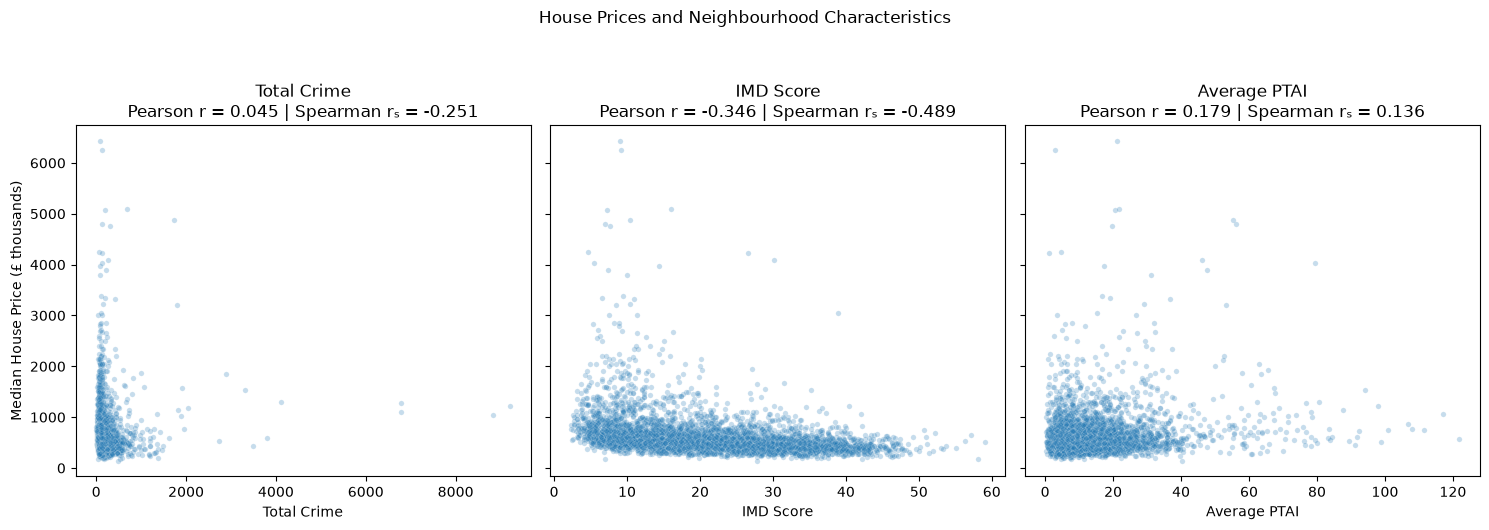

,Pearson r,Spearman r
Characteristic,,
Total Crime,0.045,-0.251
IMD Score,-0.346,-0.489
Average PTAI,0.179,0.136


In [44]:
variables = {
    "Total Crime 2022": "Total Crime",
    "IMD Score": "IMD Score",
    "Average PTAI 2015": "Average PTAI"
}

correlation_results = []

for column, label in variables.items():
    pearson_r, _ = pearsonr(df[column], df["Median House Price 2022"])
    spearman_r, _ = spearmanr(df[column], df["Median House Price 2022"])

    correlation_results.append({
        "Characteristic": label,
        "Pearson r": pearson_r,
        "Spearman r": spearman_r
    })

correlation_results = pd.DataFrame(correlation_results).set_index("Characteristic")

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, (column, label) in zip(axes, variables.items()):
    sns.scatterplot(
        x=df[column],
        y=df["Median House Price 2022"] / 1000,
        alpha=0.25,
        s=15,
        ax=ax
    )

    pearson_r = correlation_results.loc[label, "Pearson r"]
    spearman_r = correlation_results.loc[label, "Spearman r"]

    ax.set_title(
        f"{label}\n"
        f"Pearson r = {pearson_r:.3f} | Spearman rₛ = {spearman_r:.3f}"
    )
    ax.set_xlabel(label)

axes[0].set_ylabel("Median House Price (£ thousands)")
fig.suptitle("House Prices and Neighbourhood Characteristics", y=1.05)

plt.tight_layout()
plt.show()

correlation_results.round(3)

The scatterplots show several patterns that are worth exploring in more detail. Most notably, the crime plot contains a small number of LSOAs with exceptionally high recorded crime counts. Pearson correlation is close to zero, while Spearman correlation shows a clearer negative relationship, suggesting that these extreme observations may be influencing the linear correlation. These areas are examined next to understand what they represent and whether they should be retained in the analysis.

Public transport accessibility also contains several unusually high values, which are checked to confirm whether they represent genuine observations rather than data issues.

The dataset also contains more detailed measures for both crime and deprivation: crime is split into individual offence categories, while deprivation is split into separate domains such as income, employment and education. The next sections examine these measures separately to see whether some types of crime or deprivation have stronger relationships with house prices than the overall measures suggest.

**3.2 Investigating Extreme Crime Values**

The crime scatterplot shows a small number of LSOAs with exceptionally high recorded crime counts. Because these observations may have a strong influence on the Pearson correlation, they are examined more closely.

First, the 15 LSOAs with the highest total crime counts are examined to identify which areas are responsible for the most extreme values.

In [26]:
top_crime = df.nlargest(15,"Total Crime 2022")[["Local Authority Name","LSOA Name","Total Crime 2022","Median House Price 2022"]]
top_crime.style.format({"Total Crime 2022": "{:,.0f}","Median House Price 2022": "£{:,.0f}"})

,Local Authority Name,LSOA Name,Total Crime 2022,Median House Price 2022
4531,Westminster,Westminster 018A,"9,206","£1,212,500"
4557,Westminster,Westminster 013B,"8,822","£1,052,500"
4694,Westminster,Westminster 013E,"6,784","£1,270,000"
4695,Westminster,Westminster 013F,"6,784","£1,097,150"
4533,Westminster,Westminster 018C,"4,119","£1,290,000"
4682,Newham,Newham 013G,"3,792","£584,000"
2339,Hillingdon,Hillingdon 031A,"3,484","£435,500"
4532,Westminster,Westminster 018B,"3,301","£1,525,000"
4512,Westminster,Westminster 011B,"2,883","£1,850,861"
2840,Kingston upon Thames,Kingston upon Thames 009C,"2,735","£526,261"


The highest-crime LSOAs are concentrated particularly strongly in Westminster, and several of these areas combine exceptionally high crime counts with median house prices above £1 million. This raises the question of whether Westminster as a whole behaves differently from the rest of London. Before considering whether Westminster as a whole should be excluded, the borough should be compared with other London neighbourhoods.

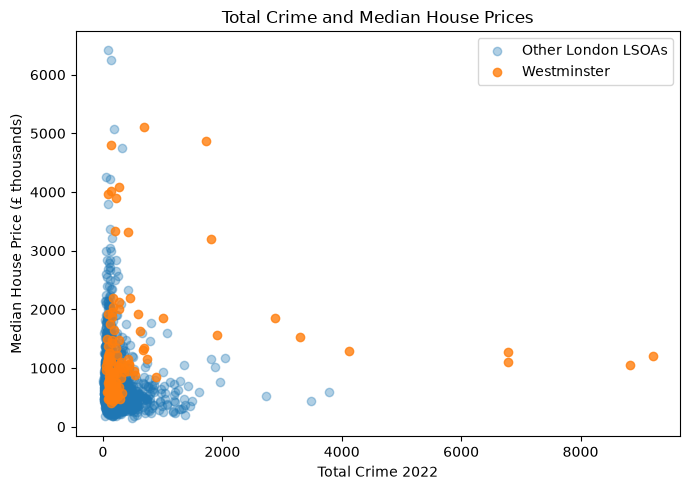

In [27]:
plt.figure(figsize=(7, 5))

westminster = df["Local Authority Name"] == "Westminster"

plt.scatter(
    df.loc[~westminster, "Total Crime 2022"],
    df.loc[~westminster, "Median House Price 2022"] / 1000,
    alpha=0.35,
    label="Other London LSOAs"
)
plt.scatter(
    df.loc[westminster, "Total Crime 2022"],
    df.loc[westminster, "Median House Price 2022"] / 1000,
    alpha=0.8,
    label="Westminster"
)
plt.xlabel("Total Crime 2022")
plt.ylabel("Median House Price (£ thousands)")
plt.title("Total Crime and Median House Prices")
plt.legend()
plt.tight_layout()
plt.show()

Although Westminster contains several of the most extreme high-crime observations, most Westminster LSOAs have crime levels similar to those seen across many other London neighbourhoods. Excluding the entire borough would therefore remove many valid observations.

The next step is to investigate the composition of crime in high-crime areas.

In [28]:
crime_cols = [
    "Arson and Criminal Damage",
    "Burglary",
    "Drug Offences",
    "Miscellaneous Crimes Against Society",
    "Possession of Weapons",
    "Public Order Offences",
    "Robbery",
    "Theft",
    "Vehicle Offences",
    "Violence Against the Person"
]

crime_cutoff = df["Total Crime 2022"].quantile(0.99)
high_crime = df[df["Total Crime 2022"] >= crime_cutoff]
other_areas = df[df["Total Crime 2022"] < crime_cutoff]
high_crime_mix = high_crime[crime_cols].sum() / high_crime["Total Crime 2022"].sum() * 100
other_crime_mix = other_areas[crime_cols].sum() / other_areas["Total Crime 2022"].sum() * 100

crime_mix = pd.DataFrame({
    "Top 1% Crime LSOAs": high_crime_mix,
    "Other LSOAs": other_crime_mix
}).sort_values("Top 1% Crime LSOAs", ascending=False)

crime_mix.round(1)

,Top 1% Crime LSOAs,Other LSOAs
Theft,59.4,23.4
Violence Against the Person,14.4,30.7
Drug Offences,5.3,5.3
Public Order Offences,4.6,7.1
Vehicle Offences,4.4,14.3
Robbery,4.3,3.1
Arson and Criminal Damage,2.7,6.9
Burglary,2.5,7.0
Miscellaneous Crimes Against Society,1.8,1.4
Possession of Weapons,0.6,0.8


The crime profile of the highest-crime LSOAs differs substantially from the rest of London. Theft accounts for 59.4% of recorded crime in the top 1% of LSOAs, compared with 23.4% elsewhere. This suggests that exceptionally high total-crime counts are disproportionately driven by theft rather than by equally high levels of all crime types. High-footfall commercial or visitor areas may contribute to this pattern, although footfall and tourism are not measured directly in this dataset.

To examine whether high-crime, theft-heavy neighbourhoods are weakening the overall relationship, a sensitivity analysis identifies LSOAs that are simultaneously:

- in the highest 25% for total crime; and
- in the highest 25% for the proportion of crime accounted for by theft.

These LSOAs are temporarily excluded and the correlations are recalculated. This does not imply that the observations are incorrect; the purpose is to assess how strongly this particular group influences the result.

In [29]:
df["Theft Share"] = df["Theft"] / df["Total Crime 2022"]

crime_q75 = df["Total Crime 2022"].quantile(0.75)
theft_q75 = df["Theft Share"].quantile(0.75)
high_crime_high_theft = ((df["Total Crime 2022"] >= crime_q75)& (df["Theft Share"] >= theft_q75))

print(f"Crime 75th percentile: {crime_q75:.0f}")
print(f"Theft-share 75th percentile: {theft_q75:.1%}")
print(f"LSOAs identified: {high_crime_high_theft.sum()}")

df_sensitivity = df[~high_crime_high_theft]
pearson_sens, pearson_p_sens = pearsonr(df_sensitivity["Total Crime 2022"], df_sensitivity["Median House Price 2022"])
spearman_sens, spearman_p_sens = spearmanr(df_sensitivity["Total Crime 2022"],df_sensitivity["Median House Price 2022"])

print(f"Pearson:  r = {pearson_sens:.3f}, p = {pearson_p_sens:.3g}")
print(f"Spearman: r = {spearman_sens:.3f}, p = {spearman_p_sens:.3g}")

Crime 75th percentile: 174
Theft-share 75th percentile: 23.3%
LSOAs identified: 671
Pearson:  r = -0.189, p = 4.87e-34
Spearman: r = -0.356, p = 5.19e-122


After temporarily excluding high-crime, theft-heavy LSOAs, Pearson correlation becomes `-0.189` and Spearman correlation becomes `-0.356`, compared with `0.045` and `-0.251` respectively in the full dataset. This indicates that theft-heavy high-crime areas weaken the overall negative relationship between crime and house prices.

However, these observations represent genuine characteristics of London neighbourhoods rather than data errors, so they are retained in the main analysis. The sensitivity analysis instead highlights an important limitation of using total crime as a single measure.

**3.3 Crime Types and House Prices**

The analysis of extreme crime values showed that the composition of crime can differ substantially between areas, with theft accounting for a particularly large share of crime in some high-crime LSOAs.

Because the dataset provides recorded crime separately by offence category, Spearman correlations are calculated for each crime type to examine whether their relationships with house prices differ from the relationship observed for total crime.

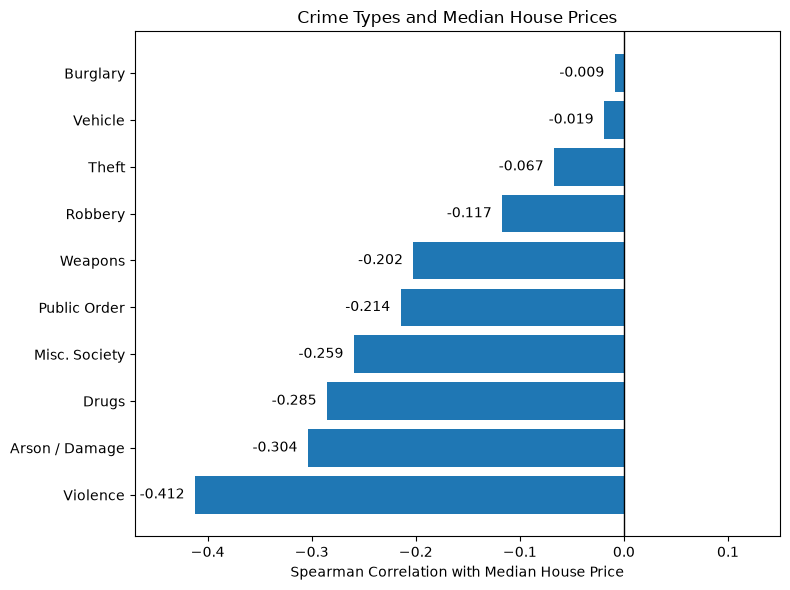

Violence Against the Person            -0.412
Arson and Criminal Damage              -0.304
Drug Offences                          -0.285
Miscellaneous Crimes Against Society   -0.259
Public Order Offences                  -0.214
Possession of Weapons                  -0.202
Robbery                                -0.117
Theft                                  -0.067
Vehicle Offences                       -0.019
Burglary                               -0.009
Name: Spearman Correlation, dtype: float64


In [51]:
crime_corr = {}

for col in crime_cols:
    r, p = spearmanr(df[col], df["Median House Price 2022"])
    crime_corr[col] = r

crime_corr = pd.Series(crime_corr, name="Spearman Correlation").sort_values()

label_map = {
    "Arson and Criminal Damage": "Arson / Damage",
    "Burglary": "Burglary",
    "Drug Offences": "Drugs",
    "Miscellaneous Crimes Against Society": "Misc. Society",
    "Possession of Weapons": "Weapons",
    "Public Order Offences": "Public Order",
    "Robbery": "Robbery",
    "Theft": "Theft",
    "Vehicle Offences": "Vehicle",
    "Violence Against the Person": "Violence"
}

plot_corr = crime_corr.copy()
plot_corr.index = [label_map[i] for i in plot_corr.index]

fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.barh(plot_corr.index, plot_corr.values)

ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Spearman Correlation with Median House Price")
ax.set_ylabel("")
ax.set_title("Crime Types and Median House Prices")

# Give a bit more space so labels do not touch plot boundaries
ax.set_xlim(-0.47, 0.15)

# Add correlation values to the bars
for bar, value in zip(bars, plot_corr.values):
    y = bar.get_y() + bar.get_height() / 2
    if value < 0:
        ax.text(value - 0.01,y,f"{value:.3f}",va="center",ha="right")
    else:
        ax.text(value + 0.01,y,f"+{value:.3f}",va="center",ha="left")

plt.tight_layout()
plt.show()

print(crime_type_corr.round(3))

The strength of the relationship with house prices varies considerably between crime types. Violence Against the Person shows the strongest negative association (`rₛ = -0.412`), followed by Arson and Criminal Damage (`rₛ = -0.304`) and Drug Offences (`rₛ = -0.285`). In contrast, Theft has only a very weak negative relationship with house prices (`rₛ = -0.067`), despite accounting for a large proportion of crime in some of the highest-crime LSOAs. Burglary and Vehicle Offences also show almost no relationship with house prices.

This demonstrates why total crime alone can be misleading: areas with similar overall crime levels may have very different crime profiles, and individual crime types have substantially different relationships with house prices.

**3.4 Deprivation Domains and House Prices**

The overall IMD Score combines several different dimensions of deprivation. Because the dataset also provides separate scores for individual deprivation domains, Spearman correlations are calculated for each domain to examine whether some dimensions have stronger relationships with house prices than the overall measure.

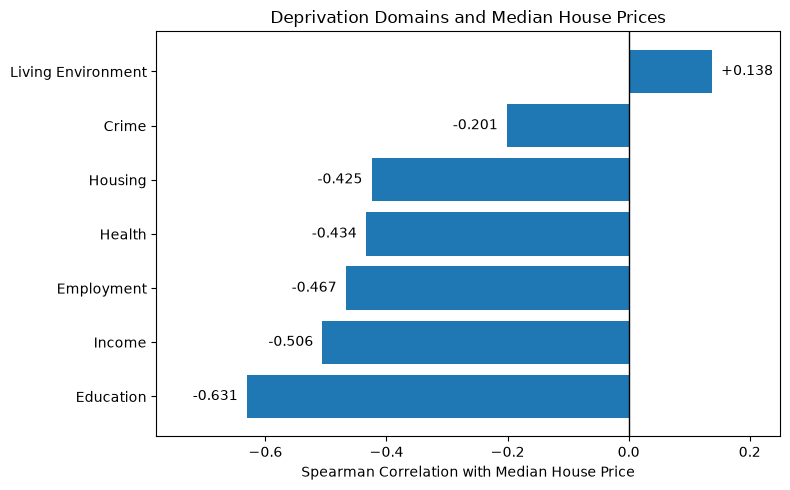

Education Deprivation Score            -0.631
Income Deprivation Score               -0.506
Employment Deprivation Score           -0.467
Health Deprivation Score               -0.434
Housing Deprivation Score              -0.425
Crime Deprivation Score                -0.201
Living Environment Deprivation Score    0.138
Name: Spearman Correlation, dtype: float64


In [48]:
deprivation_cols = [
    "Income Deprivation Score",
    "Employment Deprivation Score",
    "Education Deprivation Score",
    "Health Deprivation Score",
    "Crime Deprivation Score",
    "Housing Deprivation Score",
    "Living Environment Deprivation Score"
]

deprivation_corr = {}

for col in deprivation_cols:
    r, p = spearmanr(df[col], df["Median House Price 2022"])
    deprivation_corr[col] = r

deprivation_corr = (pd.Series(deprivation_corr, name="Spearman Correlation").sort_values())

# Shorter labels for the chart
plot_corr = deprivation_corr.copy()
plot_corr.index = plot_corr.index.str.replace(" Deprivation Score", "", regex=False)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.barh(plot_corr.index, plot_corr.values)

ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Spearman Correlation with Median House Price")
ax.set_ylabel("")
ax.set_title("Deprivation Domains and Median House Prices")
ax.set_xlim(-0.78, 0.25)

# Add correlation values to the ends of the bars
for bar, value in zip(bars, plot_corr.values):
    y = bar.get_y() + bar.get_height() / 2

    if value < 0:
        ax.text(value - 0.015, y, f"{value:.3f}", va="center", ha="right")
    else:
        ax.text(value + 0.015, y, f"+{value:.3f}", va="center", ha="left")

plt.tight_layout()
plt.show()

print(deprivation_corr.round(3))

The relationship with house prices varies considerably across deprivation domains. Education deprivation shows the strongest negative association (`rₛ = -0.631`), followed by income deprivation (`rₛ = -0.506`) and employment deprivation (`rₛ = -0.467`). Health and housing deprivation also show moderate negative associations, while Crime Deprivation has a weaker relationship with house prices.

Living Environment Deprivation is the only domain with a positive correlation (`rₛ = 0.138`), although the relationship is weak. This shows that the different dimensions of deprivation do not all have the same relationship with London house prices.

**3.5 Extreme Public Transport Accessibility Values**

The scatterplot shows a small number of LSOAs with unusually high Average PTAI values. These observations are examined to check whether they represent genuine areas with exceptionally high public transport accessibility rather than data errors.

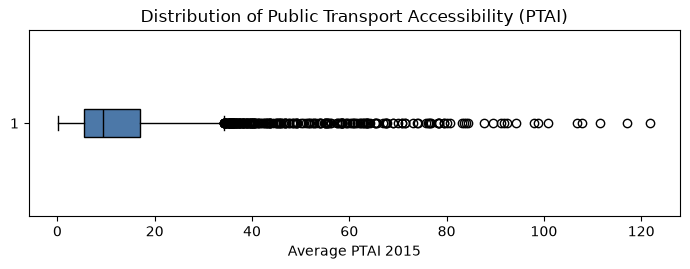

,Local Authority Name,LSOA Name,Average PTAI 2015,PTAL
4581,Southwark,Southwark 034E,121.8870,6b
4579,Lambeth,Lambeth 036E,117.0410,6b
4591,City of London,City of London 001F,111.4790,6b
2887,Lambeth,Lambeth 036D,107.8610,6b
2886,Lambeth,Lambeth 036C,106.8410,6b
4580,Southwark,Southwark 034D,100.9260,6b
3771,Southwark,Southwark 034A,98.7026,6b
4531,Westminster,Westminster 018A,97.9024,6b
4532,Westminster,Westminster 018B,94.2208,6b
3770,Southwark,Southwark 002B,92.3200,6b


In [32]:
plt.figure(figsize=(7, 2.8))

bp = plt.boxplot(df["Average PTAI 2015"],orientation="horizontal",patch_artist=True)
bp["boxes"][0].set_facecolor("#4c78a8") 
bp["medians"][0].set_color("black")
plt.title("Distribution of Public Transport Accessibility (PTAI)")
plt.xlabel("Average PTAI 2015")
plt.tight_layout()
plt.show()

df.nlargest(10,"Average PTAI 2015")[["Local Authority Name", "LSOA Name", "Average PTAI 2015", "PTAL"]]

The boxplot shows a long right tail, with a number of PTAI values beyond the standard 1.5 × IQR threshold. These observations are statistical outliers, but this does not necessarily indicate data errors.

Inspection of the LSOAs with the highest PTAI values shows that they are located in highly accessible central London areas. The extreme values therefore represent genuine differences in public transport accessibility and are retained in the analysis.

**3.6 House Prices Across PTAL Categories**

Average PTAI provides a continuous measure of public transport accessibility, while PTAL groups areas into categories representing different levels of accessibility.

To examine whether house prices differ across these accessibility categories, median house prices are compared across PTAL levels. Because house prices are strongly right-skewed and more than two independent groups are being compared, a Kruskal–Wallis test is used.

- **H₀:** House-price distributions are the same across PTAL categories.
- **H₁:** At least one PTAL category has a different house-price distribution.

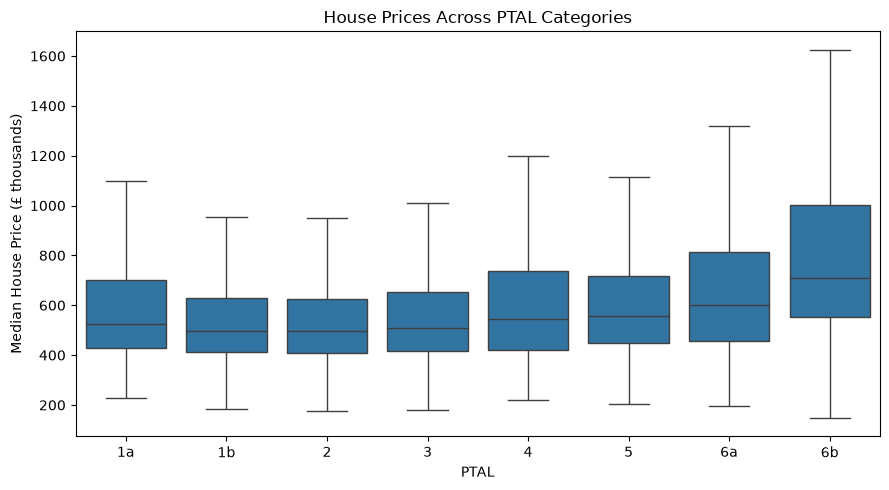

      LSOAs  Median House Price (£000s)
PTAL                                   
1a      224                       526.0
1b      803                       495.0
2      1455                       495.0
3       850                       508.0
4       546                       545.0
5       324                       555.0
6a      388                       600.0
6b      156                       708.0


In [33]:
ptal_order = ["0", "1a", "1b", "2", "3", "4", "5", "6a", "6b"]
ptal_order = [p for p in ptal_order if p in df["PTAL"].unique()]

ptal_summary = (
    df.groupby("PTAL")["Median House Price 2022"]
    .agg(["count", "median"])
    .reindex(ptal_order)
)

ptal_summary.columns = ["LSOAs", "Median House Price"]
ptal_summary["Median House Price"] = (ptal_summary["Median House Price"] / 1000).round(0)
ptal_summary.columns = ["LSOAs", "Median House Price (£000s)"]

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="PTAL",
    y=df["Median House Price 2022"] / 1000,
    order=ptal_order,
    showfliers=False
)

plt.xlabel("PTAL")
plt.ylabel("Median House Price (£ thousands)")
plt.title("House Prices Across PTAL Categories")
plt.tight_layout()
plt.show()

print(ptal_summary)

The boxplot and median values suggest that house prices generally increase at higher PTAL levels, although the pattern is not completely linear. Median prices are similar across PTAL 1b–3, at around £495,000–£508,000, before increasing from PTAL 4 onwards and reaching £708,000 in PTAL 6b. The higher PTAL categories also show a wider spread of house prices, particularly PTAL 6a and 6b.

A Kruskal–Wallis test is used next to assess whether the house-price distributions differ significantly across PTAL categories.

In [34]:
ptal_groups = [df.loc[df["PTAL"] == level, "Median House Price 2022"] for level in ptal_order]

h_stat, p_value = kruskal(*ptal_groups)

print(f"H = {h_stat:.2f}, p = {p_value:.3g}")

H = 167.23, p = 9.65e-33


The Kruskal–Wallis test shows a statistically significant difference in house-price distributions across PTAL categories (`H = 167.23`, `p < 0.001`). The null hypothesis is therefore rejected, indicating that at least one PTAL category differs from the others.

Together with the boxplot and median values, the results suggest that areas with higher public transport accessibility generally tend to have higher house prices, particularly at PTAL 6a and 6b. However, the pattern is not completely linear across all categories.

**3.7 Relationship Analysis Summary**

The exploratory analysis shows that deprivation has the clearest relationship with house prices. Higher IMD scores are associated with lower house prices, and the strength of this relationship varies across deprivation domains, with education, income and employment deprivation showing the strongest negative associations.

The relationship with crime is more complex. Total crime shows only a weak negative relationship with house prices,  partly because a small number of high-crime LSOAs have a distinctly different crime profile, with theft accounting for a much larger share of recorded offences. In the sensitivity analysis, temporarily excluding areas that were both high-crime and theft-heavy strengthened the relationship to `rₛ = -0.356` (Pearson `r = -0.189`), indicating that these areas weaken the overall crime–price relationship. They were retained in the main analysis because they represent genuine observations rather than data errors. Crime type matters: violence against the person showed a considerably stronger negative association with house prices than theft, burglary or vehicle crime, indicating that total crime alone can obscure important differences between types of offence.

Public transport accessibility shows a weaker positive relationship with house prices. The extreme PTAI values were found to represent genuine highly accessible central London areas rather than data errors. House prices also differ significantly across PTAL categories (`H = 167.23`, `p < 0.001`), with higher PTAL categories generally having higher median house prices, although the pattern is not completely linear.

These results examine each neighbourhood characteristic separately. The next section uses multiple regression to assess crime, deprivation and public transport accessibility together and compare their adjusted associations with house prices.

### 4. Multiple Regression

The previous sections examined crime, deprivation and public transport accessibility separately. Multiple regression is now used to examine how these neighbourhood characteristics are associated with house prices when considered together.

The model uses the full dataset, including the high-crime, theft-heavy LSOAs identified earlier, because these observations represent genuine neighbourhood characteristics rather than data errors.

**4.1 Preparing Variables**

House prices, total crime and PTAI are strongly right-skewed. Log transformations are therefore applied to reduce the influence of extreme values and make their relationships easier to model on a linear scale. IMD Score is retained in its original form because its distribution is relatively balanced.

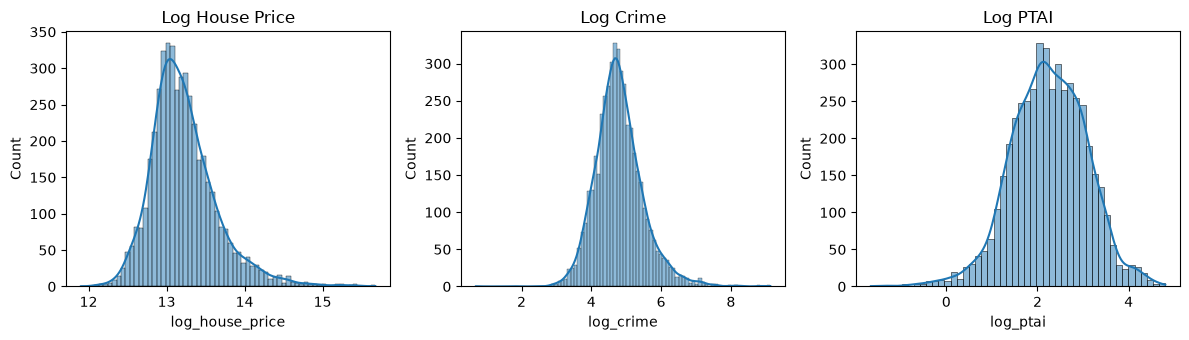

In [35]:
reg_df = pd.DataFrame({
    "log_house_price": np.log(df["Median House Price 2022"]),
    "log_crime": np.log(df["Total Crime 2022"]),
    "imd_score": df["IMD Score"],
    "log_ptai": np.log(df["Average PTAI 2015"])
})

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

sns.histplot(reg_df["log_house_price"], kde=True, ax=axes[0])
axes[0].set_title("Log House Price")

sns.histplot(reg_df["log_crime"], kde=True, ax=axes[1])
axes[1].set_title("Log Crime")

sns.histplot(reg_df["log_ptai"], kde=True, ax=axes[2])
axes[2].set_title("Log PTAI")

plt.tight_layout()
plt.show()

The transformations substantially reduce the strong right-skew in all three variables. The transformed variables are more compact and closer to symmetric distributions, making them more suitable for linear regression. The assumptions of the regression model will be assessed separately using residual diagnostics after the model is fitted.

**4.2 Multiple Regression Model**

A multiple linear regression model is fitted to examine the associations between crime, deprivation, public transport accessibility and house prices simultaneously. Using the transformed variables, the model is:

**Log House Price ~ Log Crime + IMD Score + Log PTAI**

Including all three neighbourhood characteristics allows each coefficient to represent its association with house prices while holding the other two variables constant.

In [36]:
model = smf.ols("log_house_price ~ log_crime + imd_score + log_ptai", data=reg_df).fit()
coef_table = pd.DataFrame({
    "Coefficient": model.params,
    "CI Lower": model.conf_int()[0],
    "CI Upper": model.conf_int()[1],
    "p-value": model.pvalues
}).drop("Intercept")

print(coef_table.round(4))
print(f"R²: {model.rsquared:.3f}")
print(f"Adjusted R²: {model.rsquared_adj:.3f}")
print(f"Model p-value: {model.f_pvalue:.3g}")


           Coefficient  CI Lower  CI Upper  p-value
log_crime      -0.0266   -0.0454   -0.0078   0.0056
imd_score      -0.0196   -0.0207   -0.0185   0.0000
log_ptai        0.1376    0.1233    0.1518   0.0000
R²: 0.266
Adjusted R²: 0.265
Model p-value: 3.33e-317


Because house price, crime and PTAI are log-transformed in the regression model, the coefficients can be converted into percentage changes in house prices. To make the results easier to interpret, the following calculations estimate the expected change in house prices for a 10% increase in crime and PTAI and a 10-point increase in IMD Score.

In [37]:
b_crime = model.params["log_crime"]
b_imd = model.params["imd_score"]
b_ptai = model.params["log_ptai"]

crime_10pct = (1.10 ** b_crime - 1) * 100
imd_10point = (np.exp(10 * b_imd) - 1) * 100
ptai_10pct = (1.10 ** b_ptai - 1) * 100

print(f"10% increase in total crime: {crime_10pct:.1f}%")
print(f"10-point increase in IMD: {imd_10point:.1f}%")
print(f"10% increase in PTAI: {ptai_10pct:.1f}%")

10% increase in total crime: -0.3%
10-point increase in IMD: -17.8%
10% increase in PTAI: 1.3%


The model is statistically significant (`p < 0.001`) and explains approximately **26.6% of the variation in log house prices** (`R² = 0.266`, adjusted `R² = 0.265`).

Holding the other neighbourhood characteristics constant:

- a **10% increase in total crime** is associated with house prices approximately **0.3% lower**;
- a **10-point higher IMD Score** is associated with house prices approximately **17.8% lower**;
- a **10% increase in PTAI** is associated with house prices approximately **1.3% higher**.

The initial OLS results indicate that all three predictors are statistically significant. However, the reliability of the standard errors, confidence intervals and p-values depends on the regression assumptions, which are examined in the next section.

Because the predictors are measured on different scales, their raw regression coefficients cannot be compared directly to determine which has the strongest association with house prices. To make the associations comparable, standardised regression coefficients are calculated. These express each relationship in standard-deviation units while holding the other predictors constant.

In [38]:
predictors = ["log_crime", "imd_score", "log_ptai"]

standardised_coefficients = model.params[predictors]*reg_df[predictors].std()/reg_df["log_house_price"].std()
standardised_coefficients

log_crime   -0.043222
imd_score   -0.489761
log_ptai     0.266368
dtype: float64

The standardised coefficients show that **deprivation has the strongest adjusted association with house prices** (`β = -0.490`), followed by public transport accessibility (`β = 0.266`). Crime has a much smaller adjusted association (`β = -0.043`).

This reinforces the earlier finding that deprivation has the clearest relationship with house prices. It also shows that, after accounting for deprivation and transport accessibility, total crime has a much smaller adjusted association with house prices.

**4.3 Model Diagnostics**

Linear regression relies on several assumptions about the model and its errors. Residuals — the differences between the observed and predicted log house prices — are examined to assess whether the main regression assumptions are reasonably satisfied.

The **residuals-versus-fitted plot** is used to check whether the relationships are approximately linear and whether the residuals have a roughly constant spread across predicted values. The **Q–Q plot** examines whether the residuals are approximately normally distributed. Finally, **Variance Inflation Factors (VIF)** are calculated to check whether the predictors are too strongly related to one another, which could make their individual coefficients unreliable.

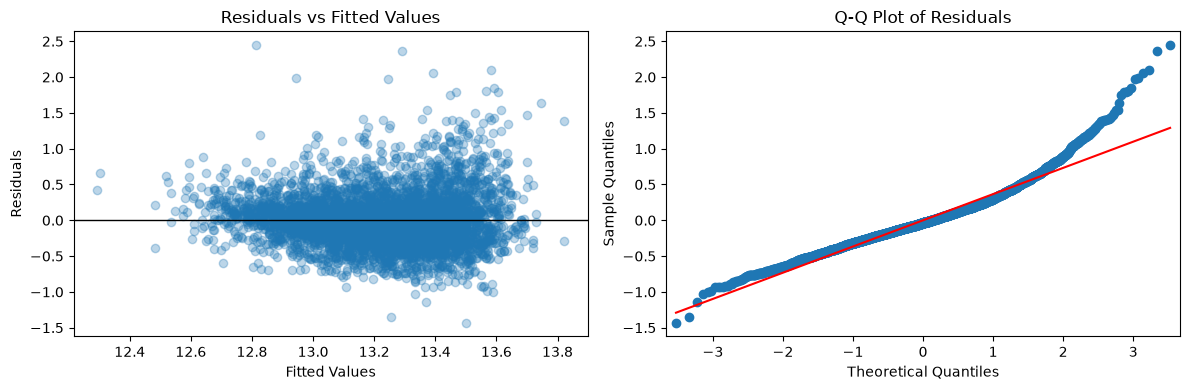

,Variable,VIF
1,log_crime,1.57
2,imd_score,1.29
3,log_ptai,1.28


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(model.fittedvalues,model.resid,alpha=0.3)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_xlabel("Fitted Values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted Values")

sm.qqplot(model.resid,line="s",ax=axes[1])
axes[1].set_title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()

X_vif = add_constant(reg_df[["log_crime", "imd_score", "log_ptai"]])

vif = pd.DataFrame({
    "Variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})

vif = vif[vif["Variable"] != "const"]
vif.round(2)

The residuals are generally centred around zero and there is no strong curved pattern, suggesting that the linear form of the model is reasonably appropriate. However, the spread of the residuals increases somewhat at higher fitted values, suggesting that the variance of the errors may not be completely constant.

The Q–Q plot follows the reference line reasonably closely through much of the distribution but deviates in the upper tail. This indicates that the residuals are not perfectly normally distributed and that some LSOAs have substantially higher house prices than the model predicts.

The VIF values are low for all three predictors (`1.57` for crime, `1.29` for IMD and `1.28` for PTAI), well below commonly used thresholds for concern. This indicates that multicollinearity is not a problem in the model. Although crime, deprivation and public transport accessibility are related to one another, the relationships are not strong enough to make their regression coefficients unstable.

The increasing spread in the residual plot suggests possible **heteroskedasticity**, meaning that the size of the model errors may vary across fitted values. A Breusch–Pagan test is used to formally assess this. The null hypothesis is that the residual variance is constant; a small p-value provides evidence that this assumption is violated.

In [40]:
bp_test = het_breuschpagan(model.resid,model.model.exog)
print(f"Breusch-Pagan p-value: {bp_test[1]:.3g}")

Breusch-Pagan p-value: 1.97e-33


The Breusch–Pagan test is statistically significant (`p < 0.001`), providing strong evidence that the residual variance is not constant.

Because heteroskedasticity can make conventional OLS standard errors, confidence intervals and p-values unreliable, **HC3 robust standard errors** are used for the final statistical inference. This adjustment does not change the regression coefficients, fitted values or R²; it only adjusts the estimated uncertainty around the coefficients.

In [41]:
robust_model = model.get_robustcov_results(cov_type="HC3")
  
robust_results = pd.DataFrame({
    "Coefficient": model.params[1:],
    "OLS p-value": model.pvalues[1:],
    "HC3 p-value": robust_model.pvalues[1:],
    "HC3 CI Lower": robust_model.conf_int()[1:, 0],
    "HC3 CI Upper": robust_model.conf_int()[1:, 1]
}, index=["log_crime", "imd_score", "log_ptai"])

robust_results.round(4)

,Coefficient,OLS p-value,HC3 p-value,HC3 CI Lower,HC3 CI Upper
log_crime,-0.0266,0.0056,0.0201,-0.0490,-0.0042
imd_score,-0.0196,0.0000,0.0000,-0.0209,-0.0183
log_ptai,0.1376,0.0000,0.0000,0.1217,0.1534


Using HC3 robust standard errors, all three predictors remain statistically significant.

The crime coefficient remains negative (`b = -0.0266`), but its p-value increases from `0.0056` under ordinary OLS to `0.0201` with robust standard errors. Its 95% robust confidence interval (`-0.0490` to `-0.0042`) remains below zero, so the negative association is still statistically significant.

The IMD coefficient remains negative (`b = -0.0196`, `p < 0.001`), while the PTAI coefficient remains positive (`b = 0.1376`, `p < 0.001`). Their conclusions are essentially unchanged after the robust adjustment.

Overall, using robust standard errors does not change the direction or statistical significance of any of the three relationships, although the evidence for the crime association becomes weaker.


**4.4 Borough Sensitivity Check**

The three characteristics in the model are all related to how central an area is: inner London areas tend to have better transport, higher recorded crime and higher prices. As a result, some of the associations observed across all London LSOAs may partly reflect broader differences between boroughs rather than differences between neighbourhoods within the same borough.

As a sensitivity check, the regression is repeated with borough included as a categorical variable, so that areas are compared only with others in the same borough. The coefficients from this borough-controlled model are compared with those from the main model to assess whether the main relationships remain similar when location at borough level is taken into account.

In [42]:
reg_df["borough"] = df["Local Authority Name"]

borough_model = smf.ols("log_house_price ~ log_crime + imd_score + log_ptai + C(borough)", data=reg_df).fit(cov_type="HC3")

comparison = pd.DataFrame({
    "Main Model": model.params[predictors],
    "Borough-Controlled Model": borough_model.params[predictors]
})

print(comparison.round(4))
print(borough_model.pvalues[predictors])

           Main Model  Borough-Controlled Model
log_crime     -0.0266                   -0.0233
imd_score     -0.0196                   -0.0205
log_ptai       0.1376                   -0.0272
log_crime     7.381706e-03
imd_score    2.044465e-284
log_ptai      1.161995e-03
dtype: float64


Crime and deprivation coefficients change very little after borough is included in the model. In contrast, the PTAI coefficient changes from `0.1376` to `-0.0272`, suggesting that its positive London-wide association with house prices is strongly related to where highly accessible areas are located within London, as inner boroughs are both better connected and more expensive. The small negative PTAI coefficient remains statistically significant (`p = 0.001`).

**4.5 Multiple Regression Summary**

The multiple regression model explains approximately **26.6% of the variation in log house prices** across London LSOAs (`R² = 0.266`, adjusted `R² = 0.265`). Substantial variation therefore remains unexplained by the model and may reflect other property, neighbourhood and location characteristics not included in the analysis.

After accounting for the other neighbourhood characteristics, all three variables remain statistically significantly associated with house prices using HC3 robust standard errors. A **10-point higher IMD Score** is associated with house prices approximately **17.8% lower** (`p < 0.001`). A **10% increase in public transport accessibility** is associated with prices approximately **1.3% higher** (`p < 0.001`), while a **10% increase in total crime** is associated with prices approximately **0.3% lower** (`p = 0.020`).

Because the predictors are measured on different scales, standardised coefficients are used to compare the relative strength of the adjusted associations. **Deprivation has the strongest association with house prices** (`β = -0.490`), followed by public transport accessibility (`β = 0.266`), while total crime has a much smaller association (`β = -0.043`).

Model diagnostics showed unequal residual variance, so HC3 robust standard errors were used. There was no evidence of problematic multicollinearity or a strong non-linear pattern in the residuals.

As an additional sensitivity check, borough was included in the model to account for broader location differences across London. The crime and deprivation coefficients changed very little, while the PTAI coefficient fell close to zero. Transport accessibility is closely linked to how central an area is, so much of its association with price reflects location within London.

Overall, deprivation has the clearest and most stable association with house prices, crime has a small negative association, and transport accessibility is positively associated with prices across London, largely because well-connected areas are concentrated in expensive inner boroughs.

### 5. Overall Conclusion

This analysis examined which of crime, deprivation and public transport accessibility is most strongly associated with median house prices across London LSOAs.

Overall, **deprivation shows the clearest and most consistent relationship with house prices**. Higher deprivation is associated with lower house prices, with education, income and employment deprivation showing particularly strong negative relationships. Deprivation also remains the strongest characteristic in the multiple regression (`β = -0.490`) and its relationship changes very little when borough differences are taken into account.

The relationship with crime is more complex. Total crime alone provides a limited picture because a small number of high-crime, theft-heavy areas weaken the overall relationship, while individual crime types show substantially different patterns. After accounting for deprivation and transport accessibility, the adjusted association between total crime and house prices is relatively small (`β = -0.043`).

Public transport accessibility is positively associated with house prices across London (`β = 0.266`), and the highest PTAL categories generally have higher median prices. However, in the borough sensitivity check the PTAI coefficient falls close to zero, which suggests that this relationship is partly explained by location: highly accessible areas are often concentrated in more expensive inner London boroughs.

The multiple regression explains approximately **26.6% of the variation in log house prices**, so these neighbourhood characteristics are relevant but account for only part of the differences in property values across London.

These findings describe statistical associations rather than causal effects. For example, deprivation may partly reflect who can afford to live in an area, not only influence its prices.

### 6. Limitations

- **Different time periods.** House prices and crime are from 2022, IMD from 2019 and public transport accessibility from 2015, so the variables do not describe exactly the same point in time.
- **Association, not causation.** This is an observational, cross-sectional analysis. Relationships may run in both directions (for example, deprivation partly reflects who can afford to live in an area) and may be driven by factors not included in the model.
- **Missing factors.** Median price depends on the mix of properties sold, such as flats versus houses, their size and tenure, which are not included. School quality and distance to central London are also not measured. The borough check controls for location only roughly, because borough is a coarse measure and centrality is not measured directly.
- **Crime measure.** Total crime is the number of recorded offences, not a rate. LSOAs have broadly similar populations, so counts are reasonably comparable between residential areas, but in high-footfall commercial and visitor areas (such as parts of Westminster) they also reflect visitors and workers, not only residents. Only one year of Metropolitan Police data is used.
- **Overlap between variables.** The IMD already includes a crime domain, so the crime and deprivation variables partly overlap. The crime coefficient shows the association with crime *in addition to* overall deprivation.
- **Data preparation.** About 250 LSOAs (around 5%) had their 2022 price estimated from nearby periods, and the crime counts of about 120 LSOAs were split across areas when converting from 2021 to 2011 boundaries. Both steps introduce small errors.
- **Statistical independence.** Neighbouring LSOAs are likely to be similar, so observations are not fully independent and p-values may be somewhat too optimistic. With nearly 5,000 areas, even small effects are statistically significant, so effect sizes matter more than p-values.